<a href="https://colab.research.google.com/github/alegouvea75/Projeto-Avaliativo-final-Modulo1/blob/main/Projeto_Avaliativo_semana_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Projeto Avaliativo final
###Importando as bibliotecas

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

### #Instalado o gdown para baixar arquivos grandes do Google Drive

In [13]:
!pip install gdown


### #baixando o aquivo Opção B E-commerce Churn lendo diretamente do projeto. Resumo visal para caber na tela.
Estrutura inicial de dados.

In [14]:
import gdown
import pandas as pd

# ID do arquivo extraído da URL fornecida
file_id = '1Gcdv7zg4BDquToRBdRwIDksHicJPO0dd'
direct_url = f'https://drive.google.com/uc?id={file_id}'
output_filename = 'ecommerce_churn.csv'
gdown.download(direct_url, output_filename, quiet=False)
df = pd.read_csv("ecommerce_churn.csv")
df.head()
# Estrutura estatística
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
print("\nTipos de dados:")
print(df.dtypes)
df.describe()
df.describe(include='object')
df.isnull().sum().sort_values(ascending=False)


Downloading...
From: https://drive.google.com/uc?id=1Gcdv7zg4BDquToRBdRwIDksHicJPO0dd
To: /content/ecommerce_churn.csv
100%|██████████| 482k/482k [00:00<00:00, 28.7MB/s]


Dimensões: 5630 linhas x 20 colunas

Tipos de dados:
CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                   int64
dtype: object


,0
DaySinceLastOrder,307
OrderAmountHikeFromlastYear,265
Tenure,264
OrderCount,258
CouponUsed,256
HourSpendOnApp,255
WarehouseToHome,251
CustomerID,0
PreferredLoginDevice,0
Churn,0


#

## #Resumo Estatístico das Variáveis Numéricas

In [16]:
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
print("\nTipos de dados:")
print(df.dtypes)
df.describe()
df.describe(include='object')
df.isnull().sum().sort_values(ascending=False)



Dimensões: 5630 linhas x 20 colunas

Tipos de dados:
CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                   int64
dtype: object


,0
DaySinceLastOrder,307
OrderAmountHikeFromlastYear,265
Tenure,264
OrderCount,258
CouponUsed,256
HourSpendOnApp,255
WarehouseToHome,251
CustomerID,0
PreferredLoginDevice,0
Churn,0


# Grafico 1

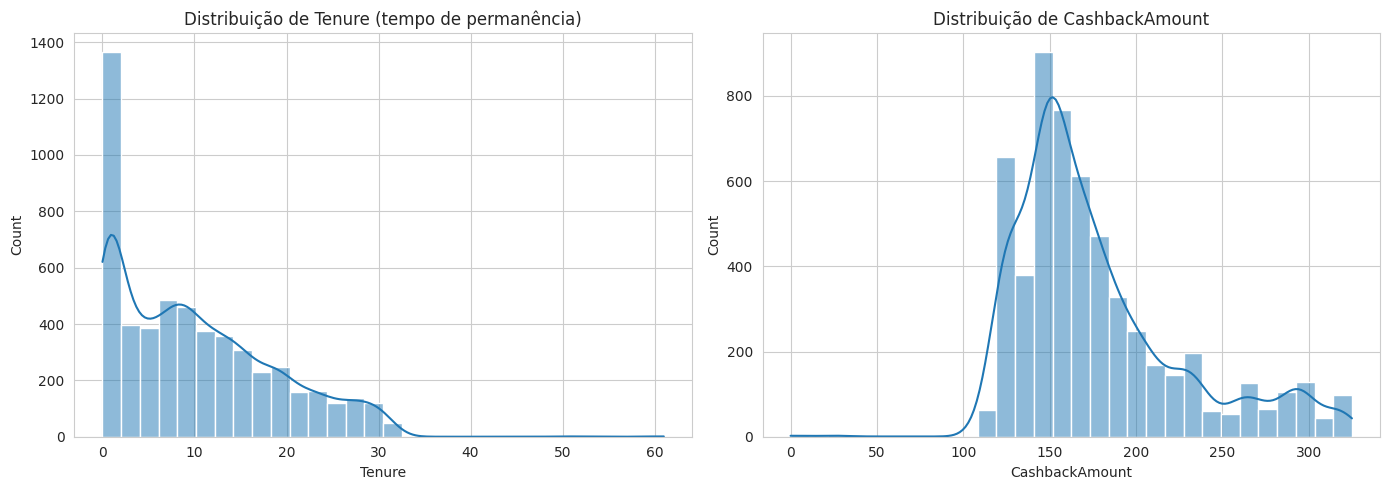

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Tenure'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Tenure (tempo de permanência)')

sns.histplot(df['CashbackAmount'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribuição de CashbackAmount')
plt.tight_layout()
plt.show()

Grafico 2

/tmp/ipykernel_2327/1720579619.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'])


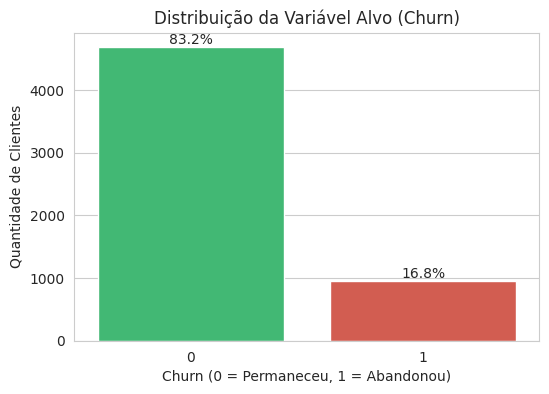

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64


In [18]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribuição da Variável Alvo (Churn)')
plt.xlabel('Churn (0 = Permaneceu, 1 = Abandonou)')
plt.ylabel('Quantidade de Clientes')

total = len(df)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.show()

print(df['Churn'].value_counts(normalize=True) * 100)

Grafico 3

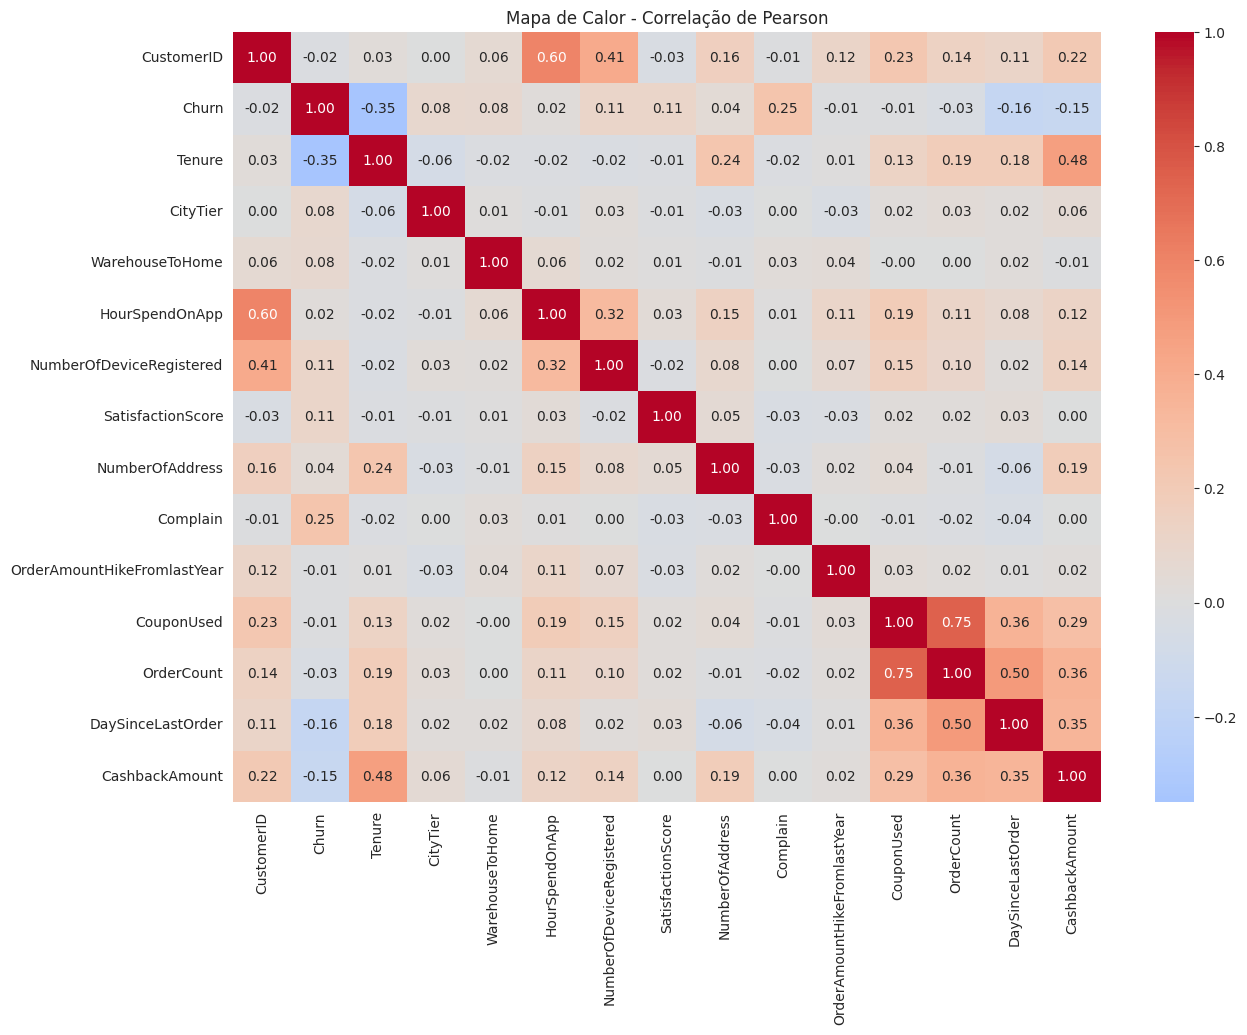

In [19]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr(method='pearson')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Mapa de Calor - Correlação de Pearson')
plt.show()